# EDA and Modelling on Albotherm dataset

This notebook follows an EDA on the albotherm dataset, trying to figure out how to achieve lower % dry in the 24 hour window.

## 1 Library and data imports

### 1.1 library imports

importing all the relevant libraries for data exploration and regression models

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold, cross_val_score
from skopt import gp_minimize

### 1.2 data imports

In [ ]:
df = pd.read_csv("../data/processed/axf_merged.csv")

df.head()


,AXF Number,Date of experiment,Aims & Hypothesis,core_batch_id,Core Formulation,Core Viscosity (cP),Amount of Core Used (g),uv_batch_id,UV formulation,UV viscosity (cP),...,manufacturing notes,On/Off at RT?,Coating compatibility?,Bulk coating compability?,% dry after 24h in humidity,% dry after 2 days in humidity chamber,Do caps look on or off at 24hrs?,Do caps turn off and/or on? at 24hrs,QC Notes,QC Pass/Fail?
0,AXF0020,2024-07-24,Baseline run,BNC00017,RAD-C-0001,4560.0,180.0,BNU00015,AUF069,228.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AXF0021,2024-07-30,Does removing PEDGA from UV remove the 'wickin...,BNC00022,RAD-C-0001,6180.0,NaN,BNU00016,AUF085,260.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AXF0022,2024-08-02,"Repeat of AXF0021, at smaller scale to create ...",BNC00017,RAD-C-0001,6852.0,180.0,BNU00017,AUF085,262.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AXF0023,2024-08-09,Size screen as a function of dispersed flow rate,BNC00017,RAD-C-0001,6756.0,180.0,BNU00018,AUF085,247.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AXF0024,2024-08-09,Size screen as a function of dispersed flow rate,BNC00017,RAD-C-0001,6756.0,180.0,BNU00018,AUF085,247.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


make sure date format is correct

In [3]:
df['Date of experiment'] = pd.to_datetime(df['Date of experiment'])


set the threshold for what is deemed succesful

In [4]:
threshold = df['% dry after 24h in humidity'].quantile(0.20) # 20% thershold for success

df['good_dry'] = df['% dry after 24h in humidity'] <= threshold

## 2 Data analysis

### 2.2 Basic plots and group comparisons

good_dry
False     8846.168558
True     10135.542484
Name: Core Viscosity (cP), dtype: float64


<Axes: xlabel='good_dry', ylabel='Core Viscosity (cP)'>

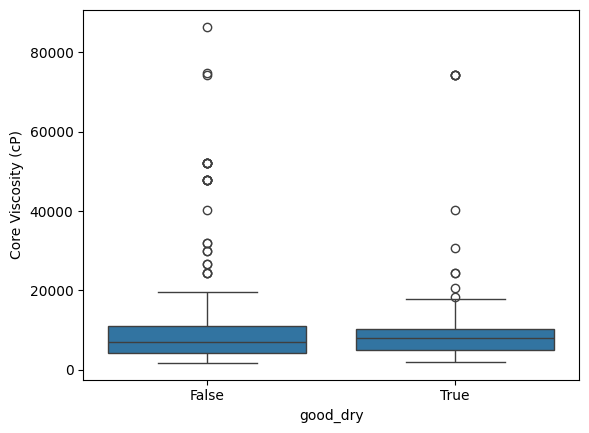

In [5]:
print(df.groupby('good_dry')['Core Viscosity (cP)'].mean())
sns.boxplot(
    x = 'good_dry',
    y = 'Core Viscosity (cP)',
    data = df
)

theres no big separation for core viscosity between succesful outcomes and unsuccessful ones

<Axes: xlabel='Flow Rate Ratio', ylabel='Core Viscosity (cP)'>

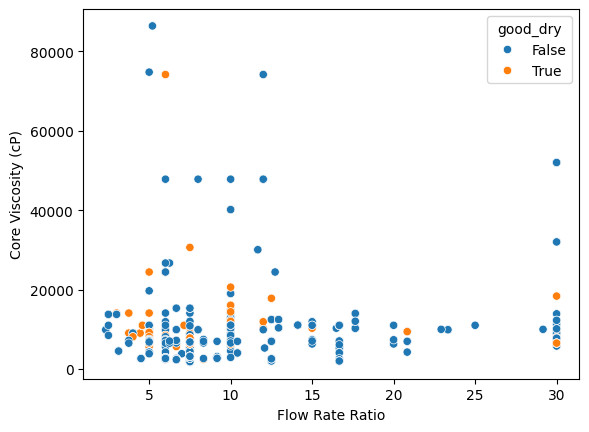

In [6]:
sns.scatterplot(
    x='Flow Rate Ratio',
    y='Core Viscosity (cP)',
    hue='good_dry',
    data=df
)

no clear trend with flow rate and core viscosity. more moderate core viscosity may contribute to successes

good_dry
False    365.161951
True     332.925490
Name: UV viscosity (cP), dtype: float64


<Axes: xlabel='good_dry', ylabel='UV viscosity (cP)'>

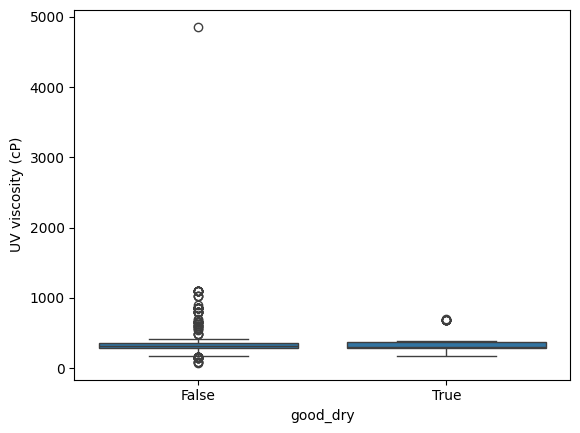

In [7]:
print(df.groupby('good_dry')['UV viscosity (cP)'].mean())
sns.boxplot(
    x = 'good_dry',
    y = 'UV viscosity (cP)',
    data = df
)

<Axes: xlabel='Flow Rate Ratio', ylabel='UV viscosity (cP)'>

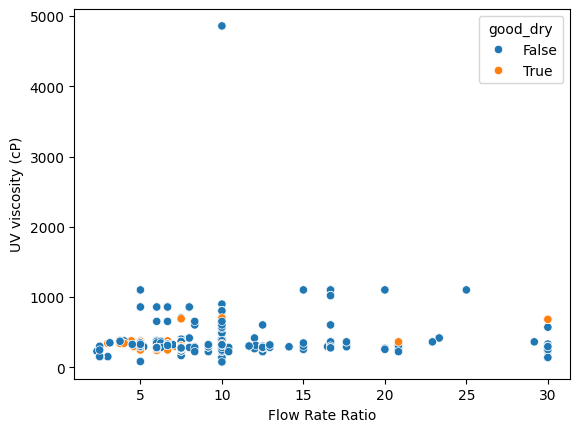

In [8]:
sns.scatterplot(
    x='Flow Rate Ratio',
    y='UV viscosity (cP)',
    hue='good_dry',
    data=df
)

similar to core viscosity + flowrate. more moderate/lower viscosities contribute to successes. though this is not by much

### 2.2 Correlations

In [9]:
corr = df.corr(numeric_only=True)
corr['% dry after 24h in humidity'].sort_values()

good_dry                                 -0.664067
Outer viscosity (cP)                     -0.154187
Amount of UV Used (g)                    -0.065943
Length of curing tubing (m)              -0.065511
Amount of Core Used (g)                  -0.053940
Curing Energy (kJ g-1)                   -0.017233
Dispersed Flow Rate (mL/min)              0.003045
Insert used (mm)                          0.006114
Core Viscosity (cP)                       0.045753
Mass of emulsion used / g                 0.049302
Core Loading (%)                          0.059052
Impellor Speed (rpm)                      0.071317
Continuous Flow Rate (mL/min)             0.083801
UV Power (J s-1)                          0.121880
Membrane Used (µm)                        0.153223
Flow Rate Ratio                           0.168198
Emulsion viscosity (cP)                   0.189040
UV viscosity (cP)                         0.213107
% dry after 2 days in humidity chamber    0.892970
% dry after 24h in humidity    

the variables with the positive correlations contribute towards higher % dries. since our goal is to get the lowest % dry possible, we want to minimise these so we can get more successes. the opposite effect, the negative correlations (outer viscosity) are contributing to % dry in the OPPOSITE direction, meaning they cause it to be lower. we want to maximise these variables.

Ill focus the dataset to the variables with most correlation

In [10]:
columns = [
    '% dry after 24h in humidity',
    'Outer viscosity (cP)',
    'UV viscosity (cP)',
    'Emulsion viscosity (cP)',
    'Flow Rate Ratio',
    'Membrane Used (µm)',
    'UV Power (J s-1)',
    'good_dry'
]

df_sub = df[columns].dropna().copy()

correlation heatmap to better illustrate relationships

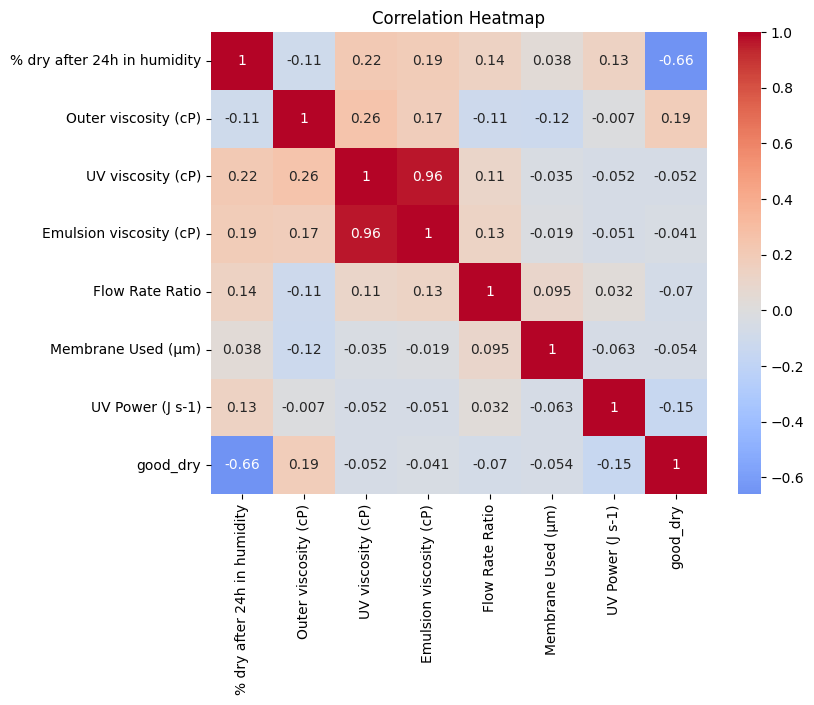

In [11]:
corr = df_sub.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

correlation heatmap indicates that viscosity related variables show the strongest relationships with % dry. UV viscosity and emulsion viscosity show moderate positive correlations, suggesting that increasesing these variables lead to higher drying levels. the extremely high correlation between UV and emulsion viscosity (r = 0.96) indicates redundancy between these features. other process variables such as flow rate ratio and UV power show weaker relationships, meaning a secondary influence on drying behaviour. furthermore, after dropping na values, membrane correlation drops to 4%.

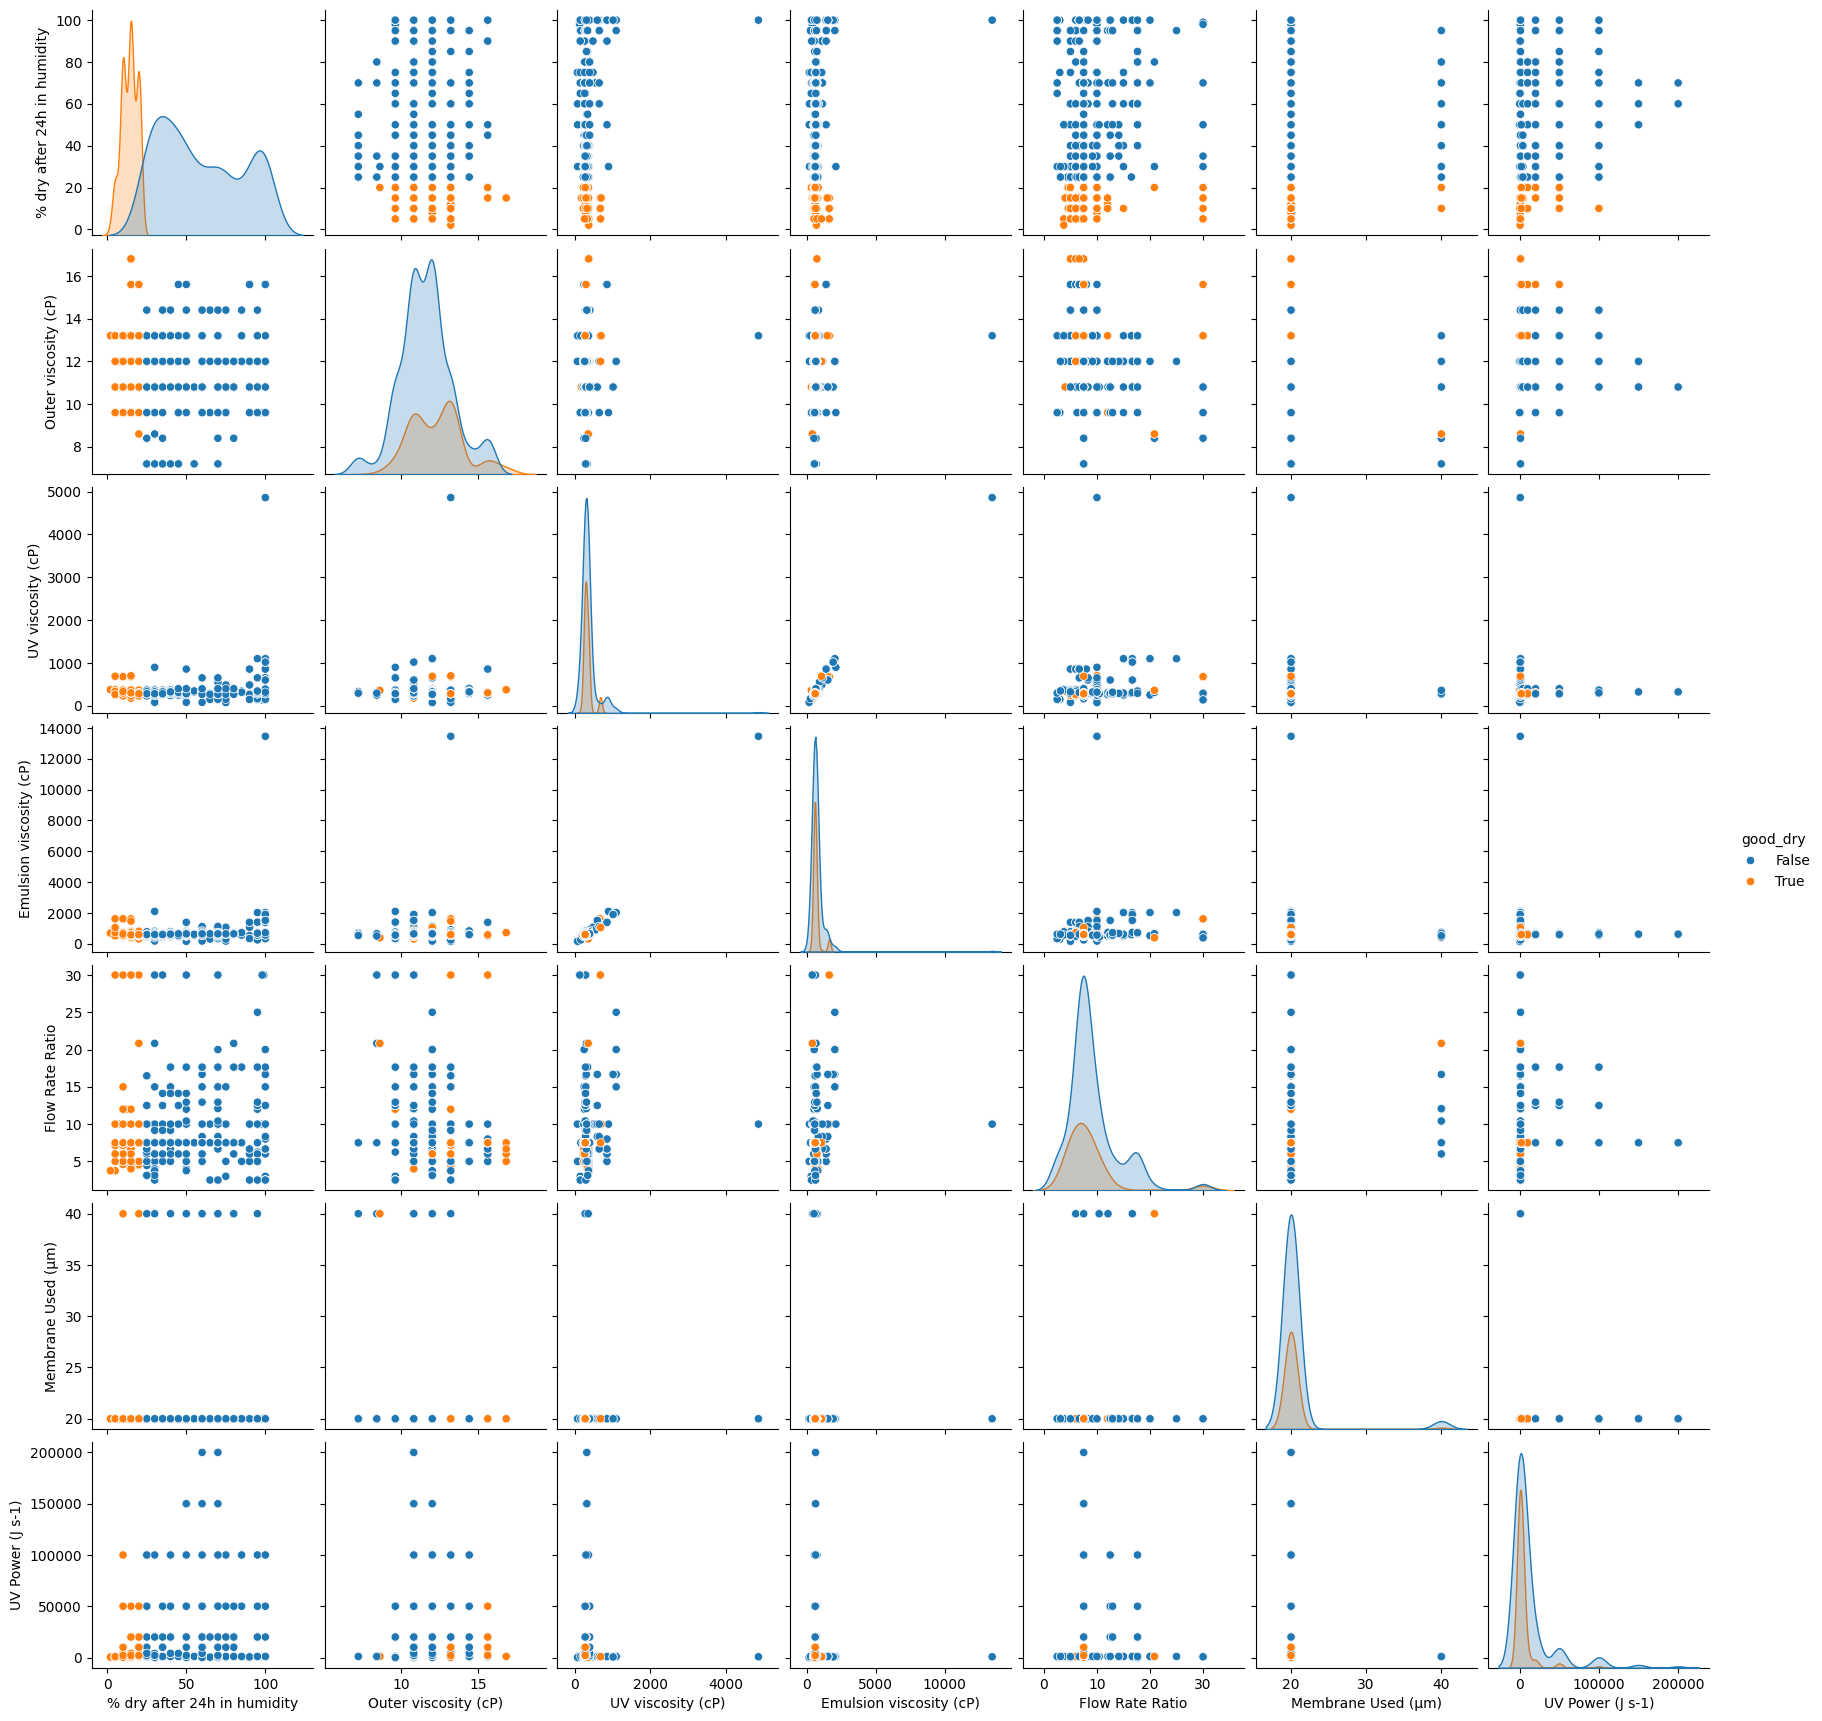

In [12]:
sns.pairplot(
    df_sub,
    hue='good_dry'
)

the pairplot reveals that UV viscosity and emulsion viscosity are highly correlated, forming a near linear relationship (also mirroring the heatmap). this confirms that they shouldnt be treated as independent predictors. while viscosity-related variables show some separation between good and poor outcomes, but variables like as flow rate ratio, UV power, and outer viscosity show less consistent and more spread out patterns. influenced by viscosity, with other process parameters playing a secondary role.

dropping emulsion viscosity due to redundancy. UV viscosity is favoured due to its higher correlation to & dry. dropping membrane as well as very weak correlation

<Axes: >

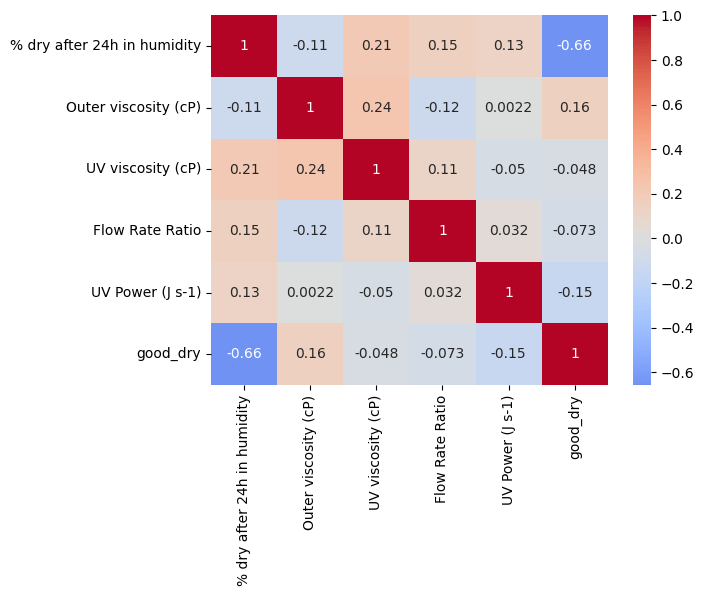

In [13]:
columns = [
    '% dry after 24h in humidity',
    'Outer viscosity (cP)',
    'UV viscosity (cP)',
    'Flow Rate Ratio',
    'UV Power (J s-1)',
    'good_dry'
]

df_sub = df[columns].dropna()

sns.heatmap(df_sub.corr(), annot=True, cmap='coolwarm', center=0)

## 3 Finding the best formulations

### 3.1 Best performing core batches

In [14]:
core_summary = df.groupby('Core Formulation').agg(
    mean_24h_dry=('% dry after 24h in humidity', 'mean'),
    success_rate=('good_dry', 'mean'),
    count=('Core Formulation', 'count'),
    mean_uv_viscosity=('UV viscosity (cP)', 'mean'),
    mean_outer_viscosity=('Outer viscosity (cP)', 'mean'),
    mean_flow_ratio=('Flow Rate Ratio', 'mean'),
    mean_uv_power=('UV Power (J s-1)', 'mean')
)

core_summary = core_summary.sort_values('success_rate', ascending=False)

core_summary.head(10)

,mean_24h_dry,success_rate,count,mean_uv_viscosity,mean_outer_viscosity,mean_flow_ratio,mean_uv_power
Core Formulation,,,,,,,
RAD-C-0004,18.000000,0.800000,5,264.000000,12.000000,10.800000,1032.000000
RAD-C-0034,38.750000,0.500000,4,324.300000,10.600000,15.416667,1032.000000
RAD-C-0009,40.000000,0.375000,8,316.650000,12.000000,10.937500,735.000000
RAD-C-0001,46.212598,0.218241,614,373.042157,11.868919,8.561735,9268.695205
RAD-C-0008,56.818182,0.153846,13,281.630769,11.076923,9.782051,910.500000
RAD-C-0002,62.083333,0.095890,73,315.764384,11.506849,13.738743,21182.166667
RAD-C-0007,89.950000,0.037037,27,290.800000,9.866667,14.089744,1008.000000
RAD-C-0003,40.000000,0.000000,4,331.200000,10.200000,13.611111,978.000000
RAD-C-0005,NaN,0.000000,1,361.200000,9.600000,16.666667,1032.000000


the most used core formulation is rad-c-0001, however the success rate is quite low. the highest success rate comes from rad-c-0004, but we only have 5 total records of it, so its not safe to say that it will always be consistent. however, it shows that the mean uv viscosity is the lower than the others, which supports the correlation maps.

### 3.2 Best performing UV formulations

In [15]:
uv_summary = df.groupby('UV formulation').agg(
    mean_24h_dry=('% dry after 24h in humidity', 'mean'),
    success_rate=('good_dry', 'mean'),
    count=('UV formulation', 'count'),
    mean_uv_viscosity=('UV viscosity (cP)', 'mean'),
    mean_outer_viscosity=('Outer viscosity (cP)', 'mean'),
    mean_flow_ratio=('Flow Rate Ratio', 'mean'),
    mean_uv_power=('UV Power (J s-1)', 'mean')
)

uv_summary = uv_summary.sort_values('success_rate', ascending=False)

uv_summary.head(10)

,mean_24h_dry,success_rate,count,mean_uv_viscosity,mean_outer_viscosity,mean_flow_ratio,mean_uv_power
UV formulation,,,,,,,
AUF075,11.000000,0.769231,13,674.500000,12.369231,17.307692,724.615385
AUF274,17.500000,0.750000,4,231.600000,10.800000,7.500000,1032.000000
AUF285,23.837209,0.613636,44,330.463636,12.872727,7.500000,29162.818182
AUF076,21.646341,0.565217,92,281.973626,11.868132,9.803824,724.488889
AUF302,20.625000,0.500000,8,312.000000,10.800000,7.500000,781.500000
AUF124,50.000000,0.333333,3,287.866667,11.600000,9.166667,654.666667
AUF333,25.833333,0.285714,7,282.000000,13.200000,7.500000,12857.142857
AUF197,28.750000,0.250000,4,272.400000,12.000000,6.000000,701.333333
AUF191,57.222222,0.200000,10,346.800000,12.720000,5.000000,748.571429


auf075 and auf274 show some promise, but they fall under the same issue of low records. auf075 however, has quite a high mean uv viscosity which is unexpected. auf274 has a lower uv viscosity mean but once again, the lack of experiments makes it hard to say if it is a good formulation.

### 3.3 Is the best combo in the dataset?

In [16]:
df[
    (df['Core Formulation'] == 'RAD-C-0004') &
    (df['UV formulation'] == 'AUF075')
]

,AXF Number,Date of experiment,Aims & Hypothesis,core_batch_id,Core Formulation,Core Viscosity (cP),Amount of Core Used (g),uv_batch_id,UV formulation,UV viscosity (cP),...,On/Off at RT?,Coating compatibility?,Bulk coating compability?,% dry after 24h in humidity,% dry after 2 days in humidity chamber,Do caps look on or off at 24hrs?,Do caps turn off and/or on? at 24hrs,QC Notes,QC Pass/Fail?,good_dry


In [17]:
df[
    (df['Core Formulation'] == 'RAD-C-0004') &
    (df['UV formulation'] == 'AUF247')
]

,AXF Number,Date of experiment,Aims & Hypothesis,core_batch_id,Core Formulation,Core Viscosity (cP),Amount of Core Used (g),uv_batch_id,UV formulation,UV viscosity (cP),...,On/Off at RT?,Coating compatibility?,Bulk coating compability?,% dry after 24h in humidity,% dry after 2 days in humidity chamber,Do caps look on or off at 24hrs?,Do caps turn off and/or on? at 24hrs,QC Notes,QC Pass/Fail?,good_dry


the highest potential performers have not been tested in combination.

## 4 Modelling

### 4.1 Data preparation

defining the features and target

In [18]:
features = [
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
    'UV Power (J s-1)'
]

target = '% dry after 24h in humidity'

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

train test split

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 4.2 Linear regression

starting with linear regression

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

R²: 0.09939048223675007
RMSE: 27.693987094435116


In [21]:
coeffs = pd.Series(model.coef_, index=features)
print(coeffs.sort_values())

Outer viscosity (cP)   -2.702790
UV Power (J s-1)        0.000143
UV viscosity (cP)       0.026637
Flow Rate Ratio         0.695271
dtype: float64


outer viscosity has a strong negative effect, indicating that increasing it will give us a lower % dry. the second strongest effect is flow rate ratio with a positive approx. 70%. this indicates that decreasing it will give us a lower % dry. UV power has little to no effect, so it will be dropped and the model will be rerun.

In [22]:
features = [
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
]

target = '% dry after 24h in humidity'

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

coeffs = pd.Series(model.coef_, index=features)
print(coeffs.sort_values())

R²: 0.031851636132850025
RMSE: 28.48856206159069
Outer viscosity (cP)   -3.191411
UV viscosity (cP)       0.026608
Flow Rate Ratio         0.955995
dtype: float64


although we got better performance for flow rate ratio and outer viscosity, r squared also significantly dropped and rmse increased. dropping membrane and uv power made the overall model weaker. with how weak r squared was initially as well, ive opted not to continue with linear regression, as its clear its not fit for our data. instead, random forest will be used as it works better with non linearity.

### 4.3 Random Forest

returning to previous feature set

In [53]:
features = [
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
    'Membrane Used (µm)',
    'UV Power (J s-1)'
]

target = '% dry after 24h in humidity'

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

implementing random forest model

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import r2_score, root_mean_squared_error

print("R²:", r2_score(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))

R²: 0.7862002106722871
RMSE: 13.4933832519583


with a significant rise of r squared of around 0.79, compared to linear regressions mere 0.10, as well as a much lower rmse, random forest proves that our problem is non linear. drying behaviour is influenced by complex interactions between process parameters such as viscosity and flow rate.

In [55]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))

UV viscosity (cP)       0.543821
Flow Rate Ratio         0.201279
UV Power (J s-1)        0.149915
Outer viscosity (cP)    0.087483
Membrane Used (µm)      0.017502
dtype: float64


now i use cross validation to ensure the r square is accurately estimated, as the 0.78 was based on a single split and likely an overestimation.

In [56]:
features = [
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
    
]

target = '% dry after 24h in humidity'

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print("Mean CV R²:", cv_scores.mean())

[0.77633184 0.56973198 0.61184959 0.75088193 0.65616964]
Mean CV R²: 0.6729929962154862


the cross validated r squared is 0.67. this is a drop of performance to a moderate prediction power, but a more accurate estimation. after experimenting with combinations of features, uv power was dropped which improved the model as well. using a gridsearch to improve the random forest will be implemented for potential improvements of the r squared

### 4.4 Tuning random forest

In [57]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R²: 0.6733957909727895


the gridsearch slightly improved the cross validated r squared. this is not the biggest jump, but it means that we are at the highest r squared we could achieve with the data.

In [58]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score, root_mean_squared_error

print("Final Test R²:", r2_score(y_test, y_pred))
print("Final RMSE:", root_mean_squared_error(y_test, y_pred))

Final Test R²: 0.729550494774039
Final RMSE: 15.057146183788694


running the final test set using the model, it achieved an r squared of 0.73. this is an increase from the cross validated 0.67, so it may be due to the specific test split being more favourable. We can run and produce a repeated cross validation score to fully ensure the r squared estimates are accurate.

In [59]:
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

scores = cross_val_score(best_rf, X, y, cv=rkf, scoring='r2')

print("Mean R²:", scores.mean())
print("Std:", scores.std())

Mean R²: 0.6869040956552047
Std: 0.048828211119226736


In [60]:
importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
print(importances.sort_values(ascending=False))

UV viscosity (cP)       0.617379
Flow Rate Ratio         0.259950
Outer viscosity (cP)    0.122670
dtype: float64


using the repeated cross val, we get a mean r squared of approx. 0.69 with a standard deviation of aproxx. 0.05.

## 5 Bayesian Optimisation

set variables for optimisation

In [72]:
opt_vars = [
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
]

set bounds

In [74]:
bounds = [
    (200, 600),          # UV viscosity (example tighter range)
    (10, 15),            # Outer viscosity
    (4, 12),             # Flow rate
]

In [75]:
def objective(params):
    u, f, p = params

    input_data = pd.DataFrame([{
        'UV viscosity (cP)': u,
        'Outer viscosity (cP)': f,
        'Flow Rate Ratio': p,
    }])

    return best_rf.predict(input_data)[0]

In [76]:
result = gp_minimize(
    objective,
    bounds,
    n_calls=40,
    random_state=42
)

print("Best predicted % dry:", result.fun)
print("Optimal values:", result.x)

Best predicted % dry: 11.535238095238093
Optimal values: [np.int64(236), np.int64(13), np.int64(6)]


bayesian optimisation identified parameter values predicted to achieve % dry below the target threshold.

In [36]:
df[df['% dry after 24h in humidity'] <= 20][[
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
    'UV Power (J s-1)',
    '% dry after 24h in humidity'
]].describe()

,UV viscosity (cP),Outer viscosity (cP),Flow Rate Ratio,UV Power (J s-1),% dry after 24h in humidity
count,153.000000,153.000000,153.000000,146.000000,153.000000
mean,332.925490,12.330719,8.257359,3929.534247,13.836601
std,103.357392,1.650091,5.031008,11638.062657,4.863204
min,178.800000,8.600000,3.000000,30.000000,2.000000
25%,282.000000,10.800000,5.000000,708.000000,10.000000
50%,298.800000,12.000000,7.500000,762.000000,15.000000
75%,367.200000,13.200000,10.000000,1032.000000,20.000000
max,702.000000,16.800000,30.000000,100000.000000,20.000000


In [37]:
successful = df[df['% dry after 24h in humidity'] <= 20]

successful[[
    'UV viscosity (cP)',
    'Outer viscosity (cP)',
    'Flow Rate Ratio',
    'UV Power (J s-1)'
]].mean()

UV viscosity (cP)        332.925490
Outer viscosity (cP)      12.330719
Flow Rate Ratio            8.257359
UV Power (J s-1)        3929.534247
dtype: float64

checking means of the variables from the dataset to ensure that the results of bayesian optimisation is within the similar region to real evidence

## Checking Random Forest with Leo's df

### Random Forest

In [17]:
df2 = pd.read_csv("df2.csv")

features = [
    'UV viscosity (cP)',
    'Miramer PU2560',
    'Batch Quantity (kg)',
    'TPO-L -Type I',
    'PEG200Da',
    
    
]

target = '% dry after 24h in humidity'

model_df2 = df2[features + [target]].dropna()

X = model_df2[features]
y = model_df2[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(random_state=42)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(cv_scores)
print("Mean CV R²:", cv_scores.mean())

[0.66860479 0.62915639 0.66136037 0.78071109 0.80186636]
Mean CV R²: 0.7083397988401032


In [18]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R²: 0.7101738996344471


In [19]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

from sklearn.metrics import r2_score, root_mean_squared_error

print("Final Test R²:", r2_score(y_test, y_pred))
print("Final RMSE:", root_mean_squared_error(y_test, y_pred))

Final Test R²: 0.765654168850412
Final RMSE: 14.622742504104172


### Bayesian Optimisation

In [21]:
opt_vars = [
    'UV viscosity (cP)',
    'Miramer PU2560',
    'Batch Quantity (kg)',
    'TPO-L -Type I',
    'PEG200Da',
    
]

In [22]:
bounds = [
    (X[var].quantile(0.05), X[var].quantile(0.95))
    for var in opt_vars
]

In [23]:
def objective(params):
    input_data = pd.DataFrame([params], columns=opt_vars)
    return best_rf.predict(input_data)[0]  # minimise predicted % dry

result = gp_minimize(
    objective,
    bounds,
    n_calls=100,
    n_initial_points=25,
    random_state=42
)

print("Best predicted % dry:", result.fun)

print("\nOptimal values:")
for name, value in zip(opt_vars, result.x):
    print(f"{name}: {value}")

Best predicted % dry: 18.289239163614162

Optimal values:
UV viscosity (cP): 239.22591882417362
Miramer PU2560: 0.0
Batch Quantity (kg): 10.5
TPO-L -Type I: 0.0
PEG200Da: 19.047619047619047


In [10]:
for var in opt_vars:
    low = X[var].quantile(0.05)
    high = X[var].quantile(0.95)
    print(var, low, high, "unique values:", X[var].nunique())

UV viscosity (cP) 164.16000000000003 804.0 unique values: 91
Miramer PU2560 0.0 625.0 unique values: 11
Batch Quantity (kg) 0.45 10.5 unique values: 33
TPO-L -Type I 0.0 600.6060606060607 unique values: 29
PEG200Da 19.047619047619047 410.04444444444533 unique values: 36
IDA 0.0 0.0 unique values: 5


### Trying to predict UV viscosity

random forest

In [24]:
target = 'UV viscosity (cP)'

features = [
    'Miramer PU2560',
    'Batch Quantity (kg)',
    'TPO-L -Type I',
    'PEG200Da',
    'IDA'
]

model_df3 = df2[features + [target]].dropna()

X_new = model_df3[features]
y_new = model_df3[target]

In [25]:
rf_uv = RandomForestRegressor(random_state=42)
rf_uv.fit(X_new, y_new)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
test_input = pd.DataFrame([{
    'Miramer PU2560': 200,
    'Batch Quantity (kg)': 5,
    'TPO-L -Type I': 150,
    'PEG200Da': 100,
    'IDA': 0
}])

print("Predicted UV viscosity:", rf_uv.predict(test_input)[0])

Predicted UV viscosity: 374.42410225589697


bayesian

In [31]:
opt_vars = features

bounds = [
    (X_new[var].min(), X_new[var].max())
    for var in opt_vars
]

def objective(params):
    input_data = pd.DataFrame([params], columns=opt_vars)
    return -rf_uv.predict(input_data)[0]

result = gp_minimize(objective, bounds, n_calls=50, random_state=42)

print("max predicted UV viscosity:", -result.fun)

for name, value in zip(opt_vars, result.x):
    print(f"{name}: {value}")

max predicted UV viscosity: 2957.6324289710283
Miramer PU2560: 10012.81217339046
Batch Quantity (kg): 11.0
TPO-L -Type I: 1105.1419322024822
PEG200Da: 0.0
IDA: 0.0


targetted prediction

In [ ]:
target_uv = 374

def objective(params):
    input_data = pd.DataFrame([params], columns=opt_vars)
    pred = rf_uv.predict(input_data)[0]
    return (pred - target_uv) ** 2

result = gp_minimize(
    objective,
    bounds,
    n_calls=200,
    n_initial_points=25,
    random_state=42
)

In [45]:
# predicted value
best_input = pd.DataFrame([result.x], columns=opt_vars)
pred_uv = rf_uv.predict(best_input)[0]

print("Target UV viscosity:", target_uv)
print("Achieved UV viscosity:", pred_uv)

for name, value in zip(opt_vars, result.x):
    print(f"{name}: {value}")

Target UV viscosity: 374
Achieved UV viscosity: 377.06399999999957
Miramer PU2560: 3363.1297337749547
Batch Quantity (kg): 2.118690803060428
TPO-L -Type I: 255.35292361749674
PEG200Da: 2000.0
IDA: 2675.3737308451277
